# EEGTCNet v3: CCST-Inspired Swin Transformer for PhysioNet

**Architecture**: CCST-style patch embedding + Swin1D Transformer (window-based attention)

Key improvements over EEGTCNet v2 (65.5% within-subject):
1. **Swin1D Transformer** (W=4, shift=2) instead of standard global attention
2. **All 64 channels** instead of 16 selected — spatial conv learns channel importance
3. **CCST-style patch embedding**: temporal conv (1x25, no pad) + standard spatial conv + AvgPool(75,15)
4. **~37 tokens** (vs 20 in v2) — more temporal resolution for the Transformer
5. **Bandpass 7-30 Hz** (vs 8-30) — captures more mu rhythm
6. **Channel-wise z-score** (no EA, no CAR) — matching CCST preprocessing
7. **CCST-style augmentation**: temporal shift +/-10 + noise sigma=0.01 + 5% electrode dropout
8. **LOSO evaluation** for direct comparison with CCST's 71.70%

**Reference**: Qamar & Abibullaev, "Multi-scale EEG feature decoding with Swin Transformers for subject independent motor imagery BCIs", Scientific Reports 2026
**CCST code**: https://github.com/WasiUrRehmanQamar/CCST

**Dataset**: PhysioNet EEG Motor Movement/Imagery (109 subjects, 64ch, 160 Hz, 2 classes)
**Experiments**: LOSO cross-subject, Within-subject 5-fold CV, Ablation studies

## 1. Imports & Configuration

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')


import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score)

def set_random_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_random_seeds(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"PyTorch: {torch.__version__}, Device: {device}")

# Dataset constants
N_SUBJECTS = 109
N_CHANNELS = 64  # ALL channels (CCST uses all 64)
SFREQ = 160 # Hz
N_CLASSES = 2 # Left Fist, Right Fist
EPOCH_SAMPLES = 641 # MNE gives 641 for tmax=4.0 @ 160Hz (CCST uses 641)

# All 6 L/R fist runs (execution + imagery)
MI_ME_RUNS = [3, 4, 7, 8, 11, 12]

BANDPASS_LOW  = 7.0 # CCST uses 7-30 Hz
BANDPASS_HIGH = 30.0

# Training (matching CCST)
LR = 3e-4
BATCH_SIZE = 72
MAX_EPOCHS = 150
PATIENCE = 10 # CCST uses patience 10

DATA_DIR = '/content/drive/My Drive/physionet_data'

print(f"Config: {N_SUBJECTS} subjects, {N_CHANNELS} ch, {SFREQ} Hz, "
      f"{N_CLASSES} classes, window={EPOCH_SAMPLES} samples")
print(f"Runs: {MI_ME_RUNS} (6 runs = 3 execution + 3 imagery)")
print(f"Bandpass: {BANDPASS_LOW}-{BANDPASS_HIGH} Hz (CCST range)")



PyTorch: 2.10.0+cu128, Device: cuda
Config: 109 subjects, 64 ch, 160 Hz, 2 classes, window=641 samples
Runs: [3, 4, 7, 8, 11, 12] (6 runs = 3 execution + 3 imagery)
Bandpass: 7.0-30.0 Hz (CCST range)


## 2. Data Loading Functions

In [2]:
def load_physionet_subject(subject_id, runs=MI_ME_RUNS, data_dir=DATA_DIR):
    """Load PhysioNet EDF files for a subject and extract motor imagery/execution epochs
       Uses all 64 channels and ALL 6 L/R fist runs
    """
    subject_name = f'S{subject_id:03d}'
    all_epochs, all_labels = [], []

    for run in runs:
        # Try both flat and subdirectory formats
        edf_path = os.path.join(data_dir, f'{subject_name}R{run:02d}.edf')
        if not os.path.exists(edf_path):
            edf_path = os.path.join(data_dir, subject_name, f'{subject_name}R{run:02d}.edf')
            if not os.path.exists(edf_path):
                continue

        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        # Resample if needed
        if raw.info['sfreq'] != SFREQ:
            raw = raw.copy().resample(SFREQ, verbose=False)

        # Clean channel names: remove trailing dots (PhysioNet/MNE convention)
        rename_map = {ch: ch.rstrip('.') for ch in raw.info['ch_names']}
        raw.rename_channels(rename_map)

        # Use ALL 64 channels (CCST approach)
        # No channel selection — let the spatial conv learn which channels matter

        # Extract events
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        mi_event_id = {k: v for k, v in event_id.items() if k in ('T1', 'T2')}

        if len(mi_event_id) < 2:
            continue

        # Create epochs: 0-4s after cue
        epochs = mne.Epochs(raw, events, event_id=mi_event_id,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        data = epochs.get_data()

        # Keep EPOCH_SAMPLES (641 for CCST compatibility)
        if data.shape[2] > EPOCH_SAMPLES:
            data = data[:, :, :EPOCH_SAMPLES]

        t1_val, t2_val = mi_event_id['T1'], mi_event_id['T2']
        for i, ev in enumerate(epochs.events[:, 2]):
            if ev == t1_val:
                all_labels.append(0)  # Left fist
                all_epochs.append(data[i])
            elif ev == t2_val:
                all_labels.append(1)  # Right fist
                all_epochs.append(data[i])

    if not all_epochs:
        return None

    return np.array(all_epochs), np.array(all_labels)


def load_all_subjects(data_dir=DATA_DIR, n_subjects=N_SUBJECTS):
    #Load PhysioNet data for N_SUBJECTS_USED subjects
    subjects_data = {}
    for sid in range(1, n_subjects + 1):
        result = load_physionet_subject(sid, data_dir=data_dir)
        if result is not None:
            X, y = result
            subjects_data[sid] = (X, y)
            print(f'  Subject {sid:03d}: {len(X)} epochs '
                  f'(Left={np.sum(y==0)}, Right={np.sum(y==1)})')
    return subjects_data


print('Data loading functions ready.')

Data loading functions ready.


## 3. Preprocessing Pipeline (CCST-aligned)

In [3]:
def bandpass_filter(X_trials, sfreq=SFREQ, low_freq=BANDPASS_LOW, high_freq=BANDPASS_HIGH, order=5):
    #FIR bandpass filter (7-30 Hz)
    nyquist = sfreq / 2
    b, a = butter(order, [low_freq / nyquist, high_freq / nyquist], btype='band')
    X_filtered = np.zeros_like(X_trials)
    for i, trial in enumerate(X_trials):
        X_filtered[i] = filtfilt(b, a, trial, axis=1)
    return X_filtered


def channel_wise_zscore(X_trials):
    #Channel-wise z-score normalization
    N, C, T = X_trials.shape
    X_flat = X_trials.reshape(N, C * T)
    mean = X_flat.mean(axis=0, keepdims=True)
    std = X_flat.std(axis=0, keepdims=True) + 1e-8
    X_normalized = (X_flat - mean) / std
    return X_normalized.reshape(N, C, T)


def channel_wise_zscore_from_train(X_train, X_test):
    #Channel-wise z-score using training set statistics only (prevent data leakage)

    N_train, C, T = X_train.shape
    N_test = X_test.shape[0]

    X_train_flat = X_train.reshape(N_train, C * T)
    mean = X_train_flat.mean(axis=0, keepdims=True)
    std = X_train_flat.std(axis=0, keepdims=True) + 1e-8

    X_train_norm = (X_train.reshape(N_train, C * T) - mean) / std
    X_test_norm = (X_test.reshape(N_test, C * T) - mean) / std

    return X_train_norm.reshape(N_train, C, T), X_test_norm.reshape(N_test, C, T)


def preprocess_per_subject(X_trials, y_trials, sfreq=SFREQ):
    #Per-subject preprocessing: bandpass + channel-wise z-score
    X = bandpass_filter(X_trials, sfreq=sfreq)
    X = channel_wise_zscore(X)
    return X, y_trials


print('Preprocessing functions ready.')

Preprocessing functions ready.


## 4. CCST-style Data Augmentation

In [4]:
def ccst_augment(X, y, shift_max=10, noise_std=0.01, dropout_rate=0.05, augment_factor=1):
    #CCST-style augmentation: temporal shift + Gaussian noise + electrode dropout

    if augment_factor == 0:
        return X, y

    X_aug_list, y_aug_list = [X], [y]

    for _ in range(augment_factor):
        X_new = X.copy()

        # Temporal shift (+-shift_max samples)
        for i in range(len(X_new)):
            shift = np.random.randint(-shift_max, shift_max + 1)
            X_new[i] = np.roll(X_new[i], shift, axis=1)

        # Gaussian noise
        X_new += np.random.randn(*X_new.shape) * noise_std

        # Electrode dropout (5%)
        for i in range(len(X_new)):
            drop_mask = np.random.rand(X_new.shape[1]) < dropout_rate
            X_new[i, drop_mask, :] = 0.0

        X_aug_list.append(X_new)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list), np.concatenate(y_aug_list)


# Quick test
np.random.seed(42)
X_test = np.random.randn(10, 64, 641)
y_test = np.array([0]*5 + [1]*5)
X_aug, y_aug = ccst_augment(X_test, y_test, augment_factor=2)
print(f'Original: {X_test.shape}, Augmented: {X_aug.shape}')
print(f'Augmentation factor: {len(y_aug) / len(y_test):.1f}x')

Original: (10, 64, 641), Augmented: (30, 64, 641)
Augmentation factor: 3.0x


## 5. Load Full Dataset

In [5]:
print(f'Loading PhysioNet data (runs {MI_ME_RUNS}, {N_CHANNELS} channels)...')

subjects_data = load_all_subjects(data_dir=DATA_DIR)

print(f'Total subjects loaded: {len(subjects_data)}')

# Summary statistics
all_counts = [len(y) for _, y in subjects_data.values()]
all_y = np.concatenate([y for _, y in subjects_data.values()])
print(f'Total epochs: {len(all_y)}')
print(f'Trials per subject: min={min(all_counts)}, max={max(all_counts)}, mean={np.mean(all_counts):.1f}')
print(f'Left Fist (T1): {np.sum(all_y==0)}, Right Fist (T2): {np.sum(all_y==1)}')
print(f'Balance: {np.sum(all_y==0)/np.sum(all_y==1):.3f}')

# Check shapes
X0 = list(subjects_data.values())[0][0]
print(f'Sample shape: {X0.shape} (should be (trials, 64, 641))')

Loading PhysioNet data (runs [3, 4, 7, 8, 11, 12], 64 channels)...
  Subject 001: 90 epochs (Left=46, Right=44)
  Subject 002: 90 epochs (Left=46, Right=44)
  Subject 003: 90 epochs (Left=45, Right=45)
  Subject 004: 90 epochs (Left=45, Right=45)
  Subject 005: 90 epochs (Left=44, Right=46)
  Subject 006: 90 epochs (Left=46, Right=44)
  Subject 007: 90 epochs (Left=46, Right=44)
  Subject 008: 90 epochs (Left=44, Right=46)
  Subject 009: 90 epochs (Left=47, Right=43)
  Subject 010: 90 epochs (Left=48, Right=42)
  Subject 011: 90 epochs (Left=45, Right=45)
  Subject 012: 90 epochs (Left=45, Right=45)
  Subject 013: 90 epochs (Left=47, Right=43)
  Subject 014: 90 epochs (Left=44, Right=46)
  Subject 015: 90 epochs (Left=45, Right=45)
  Subject 016: 90 epochs (Left=45, Right=45)
  Subject 017: 90 epochs (Left=46, Right=44)
  Subject 018: 90 epochs (Left=44, Right=46)
  Subject 019: 90 epochs (Left=47, Right=43)
  Subject 020: 90 epochs (Left=44, Right=46)
  Subject 021: 90 epochs (Left=48

## 6. Preprocessing Execution

In [6]:
print('Applying per-subject preprocessing: bandpass(7-30 Hz) + channel-wise z-score')

preprocessed_data = {}
for sid, (X, y) in subjects_data.items():
    X_pp, y_pp = preprocess_per_subject(X, y)
    preprocessed_data[sid] = (X_pp, y_pp)

print(f'Preprocessed {len(preprocessed_data)} subjects.')

# Sanity check
X0, y0 = list(preprocessed_data.values())[0]
print(f'  Sample shape: {X0.shape}, range: [{X0.min():.3f}, {X0.max():.3f}]')

Applying per-subject preprocessing: bandpass(7-30 Hz) + channel-wise z-score
Preprocessed 109 subjects.
  Sample shape: (90, 64, 641), range: [-6.966, 6.242]


## 7. Model Definition — EEGTCNet v3 (CCST-inspired Swin Transformer)

Architecture closely follows CCST (Qamar & Abibullaev, 2026):
- Patch Embedding: temporal conv (1x25) + spatial conv (Cx1) + AvgPool(75,15)
- Linear projection to d_model=64
- Learnable positional embeddings
- Swin1D Transformer (3 blocks, W=4, shift=2, 4 heads)
- GAP + Dropout + FC
~210k parameters, 37 tokens

In [7]:
# Swin1D Utilities 

def pad_sequence_1d(x, window_size):
    B, L, C = x.shape
    remainder = L % window_size
    if remainder == 0:
        return x, L, 0
    pad_len = window_size - remainder
    pad_vec = torch.zeros(B, pad_len, C, dtype=x.dtype, device=x.device)
    x_padded = torch.cat([x, pad_vec], dim=1)
    return x_padded, L, pad_len

def window_partition_1d(x, window_size):
    B, L, C = x.shape
    x_padded, orig_L, pad_len = pad_sequence_1d(x, window_size)
    Bp, Lp, Cp = x_padded.shape
    num_windows = Lp // window_size
    x_padded = x_padded.view(Bp, num_windows, window_size, Cp)
    x_windows = x_padded.reshape(Bp * num_windows, window_size, Cp)
    return x_windows, (orig_L, pad_len, num_windows)

def window_reverse_1d(x_windows, window_size, pad_info):
    orig_L, pad_len, num_windows = pad_info
    BnW, WS, C = x_windows.shape
    B = BnW // num_windows
    x_reshaped = x_windows.view(B, num_windows, WS, C)
    x_merged = x_reshaped.reshape(B, num_windows * WS, C)
    if pad_len > 0:
        x_merged = x_merged[:, :orig_L, :]
    return x_merged

def cyclic_shift_1d(x, shift_size):
    return torch.roll(x, shifts=-shift_size, dims=1)

def cyclic_shift_back_1d(x, shift_size):
    return torch.roll(x, shifts=shift_size, dims=1)


# Window Attention 

class WindowAttention1D(nn.Module):
    # Multi-head self-attention within a 1D window.
    def __init__(self, dim, num_heads, attn_dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(attn_dropout)

    def forward(self, x):
        B, L, C = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B, L, C)
        out = self.proj(out)
        out = self.proj_drop(out)
        return out


# Swin1D Block 

class Swin1DBlock(nn.Module):
    """Swin Transformer block for 1D sequences.

    Alternates between regular window attention and shifted window attention.
    Uses Pre-LN (LayerNorm before attention) for training stability.
    """
    def __init__(self, dim, num_heads, window_size=4, shift_size=2,
                 mlp_hidden=128, attn_dropout=0.1):
        super().__init__()
        self.window_size = window_size
        self.shift_size = shift_size
        self.ln1 = nn.LayerNorm(dim)
        self.attn = WindowAttention1D(dim=dim, num_heads=num_heads, attn_dropout=attn_dropout)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(attn_dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(attn_dropout)
        )

    def forward(self, x):
        # x: (B, L, dim)
        if self.shift_size > 0:
            x = cyclic_shift_1d(x, self.shift_size)

        x_windows, pad_info = window_partition_1d(x, self.window_size)

        # Pre-LN + Attention
        shortcut = x_windows
        x_windows = self.ln1(x_windows)
        x_windows = self.attn(x_windows)
        x_windows = shortcut + x_windows

        # Pre-LN + MLP
        shortcut = x_windows
        x_windows = self.ln2(x_windows)
        x_windows = self.mlp(x_windows)
        x_windows = shortcut + x_windows

        x_merged = window_reverse_1d(x_windows, self.window_size, pad_info)
        if self.shift_size > 0:
            x_merged = cyclic_shift_back_1d(x_merged, self.shift_size)
        return x_merged


# Swin1D Transformer

class Swin1DTransformer(nn.Module):
    # Stack of Swin1D blocks with alternating regular and shifted windows.
    def __init__(self, dim=64, num_layers=3, num_heads=4, mlp_hidden=128,
                 window_size=4, attn_dropout=0.1):
        super().__init__()
        blocks = []
        for i in range(num_layers):
            shift = window_size // 2 if (i % 2 == 1) else 0
            blocks.append(Swin1DBlock(
                dim=dim, num_heads=num_heads, window_size=window_size,
                shift_size=shift, mlp_hidden=mlp_hidden, attn_dropout=attn_dropout
            ))
        self.blocks = nn.ModuleList(blocks)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x.mean(dim=1)  # Global average pooling over sequence length
        return x


# Patch Embedding (CCST-style)

class PatchEmbedding(nn.Module):
    """CCST-style patch embedding: temporal conv + spatial conv + pooling.

    Closely follows the CCST implementation:
    - Temporal conv (1, 40, kernel=(1,25)) with NO padding
    - Standard spatial conv (40, 40, kernel=(C,1)) - NOT depthwise
    - BN + ELU + AvgPool(kernel=(1,75), stride=(1,15))
    - Dropout(0.5)
    - 1x1 projection to emb_size
    """
    def __init__(self, in_channels=64, input_time_len=641, emb_size=40,
                 pool_kernel=75, pool_stride=15):
        super().__init__()
        self.conv_temp = nn.Conv2d(1, 40, kernel_size=(1, 25), stride=(1, 1), padding=(0, 0))
        self.conv_spat = nn.Conv2d(40, 40, kernel_size=(in_channels, 1), stride=(1, 1), padding=(0, 0))
        self.bn = nn.BatchNorm2d(40)
        self.act = nn.ELU()
        self.pool = nn.AvgPool2d(kernel_size=(1, pool_kernel), stride=(1, pool_stride))
        self.drop = nn.Dropout(p=0.5)
        self.proj = nn.Conv2d(40, emb_size, kernel_size=(1, 1), stride=(1, 1))
        self.input_time_len = input_time_len
        self.pool_kernel = pool_kernel
        self.pool_stride = pool_stride

    def compute_seq_len(self):
        W1 = self.input_time_len - 25 + 1
        if W1 < self.pool_kernel:
            Wp = 1
        else:
            Wp = (W1 - self.pool_kernel) // self.pool_stride + 1
            Wp = max(1, Wp)
        return Wp

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.conv_temp(x)      # (B, 40, C, T-24)
        x = self.conv_spat(x)      # (B, 40, 1, T-24)
        x = self.bn(x)
        x = self.act(x)
        x = self.pool(x)           # (B, 40, 1, Wp)
        x = self.drop(x)
        x = self.proj(x)           # (B, emb_size, 1, Wp)
        x = x.squeeze(2)           # (B, emb_size, Wp)
        x = x.permute(0, 2, 1)     # (B, Wp, emb_size)
        return x


# ── EEGTCNet v3 ──

class EEGTCNetV3(nn.Module):
    def __init__(self, in_channels=64, input_time_len=641, emb_size=40,
                 swin_dim=64, num_swin_layers=3, num_heads=4,
                 mlp_hidden=128, window_size=4, num_classes=2,
                 pool_kernel=75, pool_stride=15):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            in_channels=in_channels, input_time_len=input_time_len,
            emb_size=emb_size, pool_kernel=pool_kernel, pool_stride=pool_stride
        )
        self.seq_len = self.patch_embedding.compute_seq_len()
        self.embedding_projection = nn.Linear(emb_size, swin_dim)
        self.pos_encoding = nn.Parameter(torch.zeros(1, self.seq_len, swin_dim))
        nn.init.trunc_normal_(self.pos_encoding, std=0.02)
        self.transformer = Swin1DTransformer(
            dim=swin_dim, num_layers=num_swin_layers, num_heads=num_heads,
            mlp_hidden=mlp_hidden, window_size=window_size, attn_dropout=0.1
        )
        self.classification_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(swin_dim, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.patch_embedding(x)          # (B, seq_len, emb_size)
        x = self.embedding_projection(x)     # (B, seq_len, swin_dim)
        x = x + self.pos_encoding[:, :x.size(1), :]
        features = self.transformer(x)        # (B, swin_dim)
        logits = self.classification_head(features)  # (B, num_classes)
        return logits


print('EEGTCNet v3 model defined!')

EEGTCNet v3 model defined!


## 8. Training Utilities (CCST-aligned)

In [8]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_acc = 0.0
        self.best_state = None

    def __call__(self, val_acc, model):
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
        return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        if X_t.dim() == 3:  # (B, C, T) -> add channel dim
            X_t = X_t.unsqueeze(1)  # (B, 1, C, T)
        outputs = model(X_t)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
    acc = accuracy_score(y_test, predicted.cpu().numpy())
    return acc, predicted.cpu().numpy(), probs.cpu().numpy()


def train_model_ccst(model, X_train, y_train, X_val, y_val,
                     epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
                     patience=PATIENCE, augment_factor=1, verbose=True):
    # Train with Adam + ReduceLROnPlateau (matching CCST training setup) 
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # CCST-style augmentation on training data
    X_aug, y_aug = ccst_augment(X_train, y_train, augment_factor=augment_factor)

    # Add channel dim if needed
    if X_aug.ndim == 3:
        X_aug = X_aug[:, np.newaxis, :, :]
        X_val_4d = X_val[:, np.newaxis, :, :] if X_val.ndim == 3 else X_val
    else:
        X_val_4d = X_val

    X_train_t = torch.FloatTensor(X_aug).to(device)
    y_train_t = torch.LongTensor(y_aug).to(device)
    X_val_t = torch.FloatTensor(X_val_4d).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)

    early_stopper = EarlyStopping(patience=patience)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train_t))
        epoch_loss, correct, total = 0, 0, 0

        for i in range(0, len(X_train_t), batch_size):
            X_b = X_train_t[perm[i:i+batch_size]]
            y_b = y_train_t[perm[i:i+batch_size]]
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            _, pred = torch.max(out, 1)
            total += y_b.size(0)
            correct += (pred == y_b).sum().item()

        train_loss = epoch_loss / (len(X_train_t) // batch_size + 1)
        train_acc = correct / total

        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            _, val_pred = torch.max(val_out, 1)
            val_acc = (val_pred == y_val_t).sum().item() / len(y_val_t)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} | Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}')

        if early_stopper(val_acc, model):
            if verbose:
                print(f'  Early stopping at epoch {epoch+1}')
            model = early_stopper.restore(model)
            break

    return history


print('Training utilities ready.')

Training utilities ready.


## 9. Model Summary

In [9]:
model = EEGTCNetV3(in_channels=64, input_time_len=EPOCH_SAMPLES, num_classes=N_CLASSES)
total_params, trainable_params = count_parameters(model)
print('EEGTCNet v3 Architecture')
print(f'Parameters: total={total_params:,}  trainable={trainable_params:,}')
print(f'Sequence length (tokens): {model.seq_len}')

# Per-module breakdown
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f'  {name}: {params:,}')

# Shape test
dummy = torch.randn(2, 1, N_CHANNELS, EPOCH_SAMPLES)
out = model(dummy)
print(f'\nInput:  {dummy.shape}')
print(f'Output: {out.shape}')

# Compare with v2
print(f'\nComparison with EEGTCNet v2:')
print(f'  v2: 72,178 params, 20 tokens, 16 channels, standard Transformer')
print(f'  v3: {total_params:,} params, {model.seq_len} tokens, 64 channels, Swin Transformer')

EEGTCNet v3 Architecture
Parameters: total=210,290  trainable=210,290
Sequence length (tokens): 37
  patch_embedding: 105,200
  embedding_projection: 2,624
  transformer: 99,968
  classification_head: 130

Input:  torch.Size([2, 1, 64, 641])
Output: torch.Size([2, 2])

Comparison with EEGTCNet v2:
  v2: 72,178 params, 20 tokens, 16 channels, standard Transformer
  v3: 210,290 params, 37 tokens, 64 channels, Swin Transformer


## 10. Experiment 1: LOSO Cross-Subject Evaluation

Leave-One-Subject-Out evaluation matching CCST's protocol.
For each of 109 subjects: train on 108, test on 1.
10% of training data for validation (early stopping).
Target: match or exceed CCST's 71.70%.

In [10]:
print('Experiment 1: LOSO Cross-Subject Evaluation (CCST protocol)')

all_sids = sorted(preprocessed_data.keys())
loso_results = []

for fold_i, test_sid in enumerate(all_sids):
    print(f'\n--- Fold {fold_i+1}/{len(all_sids)}: Test subject {test_sid:03d} ---')

    train_sids = [s for s in all_sids if s != test_sid]
    X_train_arr = np.concatenate([preprocessed_data[s][0] for s in train_sids])
    y_train_arr = np.concatenate([preprocessed_data[s][1] for s in train_sids])
    X_test_arr, y_test_arr = preprocessed_data[test_sid]

    # Channel-wise z-score from training set only (prevent data leakage)
    X_train_norm, X_test_norm = channel_wise_zscore_from_train(X_train_arr, X_test_arr)

    # Split training: 90% train, 10% validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_norm, y_train_arr, test_size=0.1,
        stratify=y_train_arr, random_state=42+fold_i
    )

    # Build fresh model
    model_loso = EEGTCNetV3(
        in_channels=N_CHANNELS, input_time_len=EPOCH_SAMPLES, num_classes=N_CLASSES
    )

    history = train_model_ccst(
        model_loso, X_tr, y_tr, X_val, y_val,
        epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
        patience=PATIENCE, augment_factor=1, verbose=True
    )

    acc, _, _ = evaluate_model(model_loso, X_test_norm, y_test_arr)
    loso_results.append({'subject': test_sid, 'accuracy': acc})
    print(f'  Test subject {test_sid:03d}: acc={acc:.4f} ({acc*100:.1f}%)')

loso_accs = np.array([r['accuracy'] for r in loso_results])

print(f'LOSO Mean Accuracy: {loso_accs.mean():.4f} +/- {loso_accs.std():.4f}')
print(f'Min: {loso_accs.min():.4f}, Max: {loso_accs.max():.4f}, Median: {np.median(loso_accs):.4f}')
print(f'CCST benchmark (LOSO): 71.70%')
print(f'Above chance (>50%): {np.sum(loso_accs > 0.5)}/{len(loso_results)}')

Experiment 1: LOSO Cross-Subject Evaluation (CCST protocol)

--- Fold 1/109: Test subject 001 ---
  Epoch  10 | Train: 0.4046/0.8146 | Val: 0.4809/0.7508
  Epoch  20 | Train: 0.2813/0.8806 | Val: 0.5653/0.7662
  Early stopping at epoch 22
  Test subject 001: acc=0.7889 (78.9%)

--- Fold 2/109: Test subject 002 ---
  Epoch  10 | Train: 0.4254/0.8040 | Val: 0.4571/0.7889
  Epoch  20 | Train: 0.2930/0.8750 | Val: 0.4835/0.7878
  Early stopping at epoch 23
  Test subject 002: acc=0.9000 (90.0%)

--- Fold 3/109: Test subject 003 ---
  Epoch  10 | Train: 0.4196/0.8050 | Val: 0.4586/0.7734
  Epoch  20 | Train: 0.2789/0.8817 | Val: 0.4446/0.8033
  Epoch  30 | Train: 0.2126/0.9102 | Val: 0.4807/0.8033
  Early stopping at epoch 36
  Test subject 003: acc=0.8000 (80.0%)

--- Fold 4/109: Test subject 004 ---
  Epoch  10 | Train: 0.4200/0.8056 | Val: 0.4493/0.7858
  Early stopping at epoch 18
  Test subject 004: acc=0.9111 (91.1%)

--- Fold 5/109: Test subject 005 ---
  Epoch  10 | Train: 0.4205/0.

## 11. Experiment 2: Within-Subject Evaluation (5-Fold Stratified CV)

Same protocol as EEGTCNet v2 for direct comparison.

In [11]:
N_FOLDS = 5

print(f'Experiment 2: Within-Subject Evaluation ({N_FOLDS}-Fold Stratified CV)')

within_results_v3 = []

for sid in sorted(preprocessed_data.keys()):
    X, y = preprocessed_data[sid]
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Channel-wise z-score from training set only
        X_tr_norm, X_te_norm = channel_wise_zscore_from_train(X_tr, X_te)

        model_ws = EEGTCNetV3(
            in_channels=N_CHANNELS, input_time_len=EPOCH_SAMPLES, num_classes=N_CLASSES
        )
        history = train_model_ccst(
            model_ws, X_tr_norm, y_tr, X_te_norm, y_te,
            epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
            patience=PATIENCE, augment_factor=1, verbose=False
        )
        acc, _, _ = evaluate_model(model_ws, X_te_norm, y_te)
        fold_accs.append(acc)

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    within_results_v3.append({
        'subject': sid, 'accuracy': mean_acc, 'std': std_acc,
        'fold_accs': fold_accs, 'n_trials': len(y)
    })
    print(f'  Subject {sid:03d}: {mean_acc:.4f} +/- {std_acc:.4f} ({mean_acc*100:.1f}% +/- {std_acc*100:.1f}%) '
          f'[folds={", ".join(f"{a:.2f}" for a in fold_accs)}]')

within_accs_v3 = np.array([r['accuracy'] for r in within_results_v3])

print(f'Within-Subject v3 Mean Accuracy: {within_accs_v3.mean():.4f} +/- {within_accs_v3.std():.4f}')
print(f'Min: {within_accs_v3.min():.4f}, Max: {within_accs_v3.max():.4f}, Median: {np.median(within_accs_v3):.4f}')
print(f'v2 comparison: 65.5% +/- 13.5%')
print(f'Above chance (>50%): {np.sum(within_accs_v3 > 0.5)}/{len(within_results_v3)}')

Experiment 2: Within-Subject Evaluation (5-Fold Stratified CV)
  Subject 001: 0.7333 +/- 0.1423 (73.3% +/- 14.2%) [folds=0.50, 0.72, 0.78, 0.72, 0.94]
  Subject 002: 0.8222 +/- 0.1587 (82.2% +/- 15.9%) [folds=0.94, 0.72, 0.94, 0.94, 0.56]
  Subject 003: 0.6222 +/- 0.0956 (62.2% +/- 9.6%) [folds=0.56, 0.78, 0.67, 0.61, 0.50]
  Subject 004: 0.6111 +/- 0.0703 (61.1% +/- 7.0%) [folds=0.72, 0.67, 0.56, 0.56, 0.56]
  Subject 005: 0.6222 +/- 0.0737 (62.2% +/- 7.4%) [folds=0.61, 0.72, 0.67, 0.50, 0.61]
  Subject 006: 0.6222 +/- 0.1333 (62.2% +/- 13.3%) [folds=0.50, 0.72, 0.83, 0.50, 0.56]
  Subject 007: 0.7778 +/- 0.1571 (77.8% +/- 15.7%) [folds=0.72, 0.83, 0.94, 0.50, 0.89]
  Subject 008: 0.6778 +/- 0.0416 (67.8% +/- 4.2%) [folds=0.72, 0.67, 0.72, 0.67, 0.61]
  Subject 009: 0.5333 +/- 0.0272 (53.3% +/- 2.7%) [folds=0.50, 0.56, 0.56, 0.50, 0.56]
  Subject 010: 0.7556 +/- 0.1247 (75.6% +/- 12.5%) [folds=0.72, 0.72, 0.89, 0.56, 0.89]
  Subject 011: 0.5667 +/- 0.0416 (56.7% +/- 4.2%) [folds=0.50,

## 12. Results Visualization

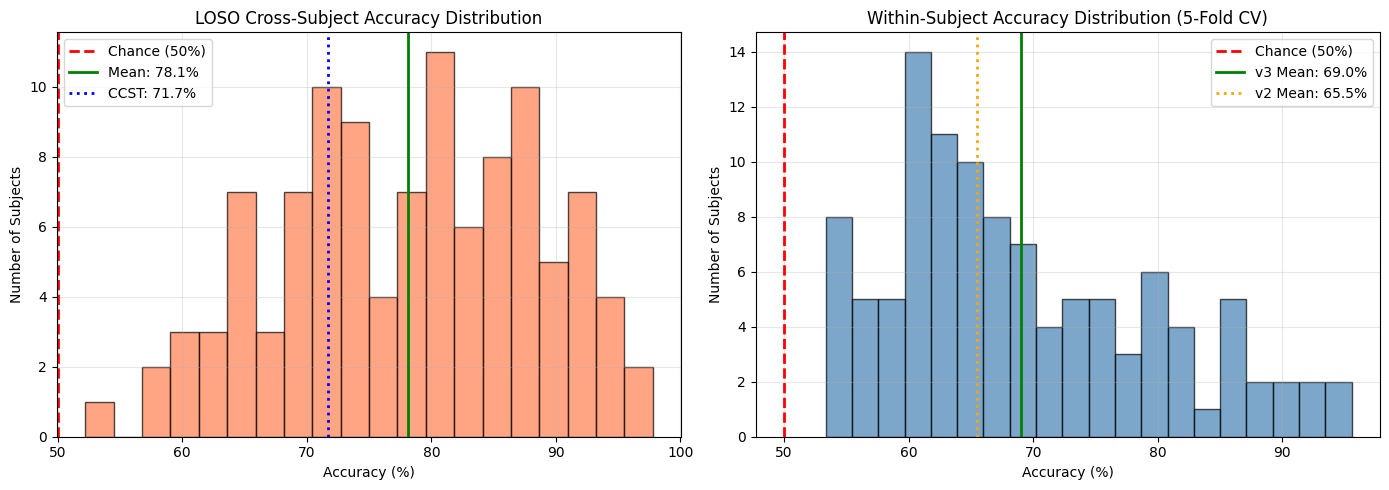

In [12]:
# LOSO results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOSO histogram
axes[0].hist(loso_accs * 100, bins=20, color='coral', alpha=0.7, edgecolor='black')
axes[0].axvline(x=50, color='red', ls='--', lw=2, label='Chance (50%)')
axes[0].axvline(x=loso_accs.mean()*100, color='green', ls='-', lw=2,
                label=f'Mean: {loso_accs.mean()*100:.1f}%')
axes[0].axvline(x=71.70, color='blue', ls=':', lw=2, label='CCST: 71.7%')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_ylabel('Number of Subjects')
axes[0].set_title('LOSO Cross-Subject Accuracy Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Within-subject histogram
axes[1].hist(within_accs_v3 * 100, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(x=50, color='red', ls='--', lw=2, label='Chance (50%)')
axes[1].axvline(x=within_accs_v3.mean()*100, color='green', ls='-', lw=2,
                label=f'v3 Mean: {within_accs_v3.mean()*100:.1f}%')
axes[1].axvline(x=65.5, color='orange', ls=':', lw=2, label='v2 Mean: 65.5%')
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_ylabel('Number of Subjects')
axes[1].set_title('Within-Subject Accuracy Distribution (5-Fold CV)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eegtcnet_v3_physionet_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Ablation Studies

Investigate the contribution of each major architectural choice.

**Ablation 1**: Swin vs Standard Transformer — Does window-based attention help?
**Ablation 2**: 64 vs 16 channels — Does using all channels improve accuracy?
**Ablation 3**: CCST augmentation vs No augmentation — How much does augmentation help?
**Ablation 4**: Token count — How does pool kernel/stride affect accuracy?

Each ablation uses 5-fold CV on a subset of subjects (10 for Ablations 1-3, 5 for Ablation 4).

In [13]:
# ── Ablation helper: Standard Transformer (no window attention) ──

class StandardTransformerBlock(nn.Module):
    """Standard Pre-LN Transformer block (global attention, no windows)."""
    def __init__(self, dim, num_heads, mlp_hidden=128, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: (B, L, dim)
        shortcut = x
        x = self.ln1(x)
        x_attn, _ = self.attn(x, x, x)
        x = shortcut + x_attn
        shortcut = x
        x = self.ln2(x)
        x = shortcut + self.mlp(x)
        return x


class StandardTransformer(nn.Module):
    """Stack of standard Transformer blocks for comparison with Swin."""
    def __init__(self, dim=64, num_layers=3, num_heads=4, mlp_hidden=128, dropout=0.1):
        super().__init__()
        blocks = [StandardTransformerBlock(dim=dim, num_heads=num_heads,
                                           mlp_hidden=mlp_hidden, dropout=dropout)
                  for _ in range(num_layers)]
        self.blocks = nn.ModuleList(blocks)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x.mean(dim=1)  # GAP
        return x


class EEGTCNetV3_StandardTransformer(nn.Module):
    """Same as EEGTCNetV3 but with standard global-attention Transformer."""
    def __init__(self, in_channels=64, input_time_len=641, emb_size=40,
                 swin_dim=64, num_layers=3, num_heads=4,
                 mlp_hidden=128, num_classes=2,
                 pool_kernel=75, pool_stride=15):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            in_channels=in_channels, input_time_len=input_time_len,
            emb_size=emb_size, pool_kernel=pool_kernel, pool_stride=pool_stride
        )
        self.seq_len = self.patch_embedding.compute_seq_len()
        self.embedding_projection = nn.Linear(emb_size, swin_dim)
        self.pos_encoding = nn.Parameter(torch.zeros(1, self.seq_len, swin_dim))
        nn.init.trunc_normal_(self.pos_encoding, std=0.02)
        self.transformer = StandardTransformer(
            dim=swin_dim, num_layers=num_layers, num_heads=num_heads,
            mlp_hidden=mlp_hidden, dropout=0.1
        )
        self.classification_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(swin_dim, num_classes)
        )

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.embedding_projection(x)
        x = x + self.pos_encoding[:, :x.size(1), :]
        features = self.transformer(x)
        logits = self.classification_head(features)
        return logits


# 16-channel variant 

SELECTED_CHANNELS_16 = [
    'Fp1', 'F3', 'F4', 'C3', 'Cz', 'C4',
    'P3', 'Pz', 'P4', 'F7', 'F8',
    'T7', 'T8', 'P7', 'P8', 'Fz'
]

def load_physionet_subject_16ch(subject_id, runs=MI_ME_RUNS, data_dir=DATA_DIR):
    """Load with 16 selected channels (same as v2)."""
    subject_name = f'S{subject_id:03d}'
    all_epochs, all_labels = [], []

    for run in runs:
        edf_path = os.path.join(data_dir, f'{subject_name}R{run:02d}.edf')
        if not os.path.exists(edf_path):
            edf_path = os.path.join(data_dir, subject_name, f'{subject_name}R{run:02d}.edf')
            if not os.path.exists(edf_path):
                continue

        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        if raw.info['sfreq'] != SFREQ:
            raw = raw.copy().resample(SFREQ, verbose=False)

        rename_map = {ch: ch.rstrip('.') for ch in raw.info['ch_names']}
        raw.rename_channels(rename_map)

        available = raw.info['ch_names']
        pick_channels = [ch for ch in SELECTED_CHANNELS_16 if ch in available]
        if len(pick_channels) < 16:
            continue
        raw.pick(pick_channels[:16])

        events, event_id = mne.events_from_annotations(raw, verbose=False)
        mi_event_id = {k: v for k, v in event_id.items() if k in ('T1', 'T2')}
        if len(mi_event_id) < 2:
            continue

        epochs = mne.Epochs(raw, events, event_id=mi_event_id,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        data = epochs.get_data()
        if data.shape[2] > EPOCH_SAMPLES:
            data = data[:, :, :EPOCH_SAMPLES]

        t1_val, t2_val = mi_event_id['T1'], mi_event_id['T2']
        for i, ev in enumerate(epochs.events[:, 2]):
            if ev == t1_val:
                all_labels.append(0)
                all_epochs.append(data[i])
            elif ev == t2_val:
                all_labels.append(1)
                all_epochs.append(data[i])

    if not all_epochs:
        return None
    return np.array(all_epochs), np.array(all_labels)


# Quick ablation runner 

def run_ablation_5fold(X, y, model_class, model_kwargs, n_folds=5, epochs=50,
                       lr=3e-4, batch_size=32, augment_factor=0):
    # Run a quick 5-fold CV ablation on given data with given model.
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        X_tr_norm, X_te_norm = channel_wise_zscore_from_train(X_tr, X_te)

        model = model_class(**model_kwargs).to(device)
        history = train_model_ccst(
            model, X_tr_norm, y_tr, X_te_norm, y_te,
            epochs=epochs, lr=lr, batch_size=batch_size,
            patience=15, augment_factor=augment_factor, verbose=False
        )
        acc, _, _ = evaluate_model(model, X_te_norm, y_te)
        fold_accs.append(acc)

    return np.mean(fold_accs), np.std(fold_accs)


print('Ablation utilities defined!')
print(f'Standard Transformer model params: {sum(p.numel() for p in EEGTCNetV3_StandardTransformer().parameters()):,}')
print(f'Swin Transformer model params: {sum(p.numel() for p in EEGTCNetV3().parameters()):,}')
print(f'Selected 16 channels: {SELECTED_CHANNELS_16}')

Ablation utilities defined!
Standard Transformer model params: 210,866
Swin Transformer model params: 210,290
Selected 16 channels: ['Fp1', 'F3', 'F4', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz']


## 14. Ablation 1: Swin vs Standard Transformer

In [14]:
ABLATION_SUBJECTS = 10  # Quick ablation on 10 subjects
ABLATION_EPOCHS = 50 # Fewer epochs for speed

print(f'Ablation 1: Swin vs Standard Transformer ({ABLATION_SUBJECTS} subjects, {ABLATION_EPOCHS} epochs)')

ablation_sids = sorted(preprocessed_data.keys())[:ABLATION_SUBJECTS]
swin_accs = []
standard_accs = []

for sid in ablation_sids:
    X, y = preprocessed_data[sid]

    # Swin (our v3 model)
    mean_swin, std_swin = run_ablation_5fold(
        X, y, EEGTCNetV3,
        model_kwargs={'in_channels': N_CHANNELS, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES},
        epochs=ABLATION_EPOCHS, batch_size=32, augment_factor=1
    )
    swin_accs.append(mean_swin)

    # Standard Transformer (same architecture, global attention)
    mean_std, std_std = run_ablation_5fold(
        X, y, EEGTCNetV3_StandardTransformer,
        model_kwargs={'in_channels': N_CHANNELS, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES},
        epochs=ABLATION_EPOCHS, batch_size=32, augment_factor=1
    )
    standard_accs.append(mean_std)

    print(f'  Subject {sid:03d}: Swin={mean_swin*100:.1f}% +/- {std_swin*100:.1f}%, Standard={mean_std*100:.1f}% +/- {std_std*100:.1f}%')

swin_arr = np.array(swin_accs)
std_arr = np.array(standard_accs)
print(f'\nAblation 1 Results ({ABLATION_SUBJECTS} subjects):')
print(f'  Swin Transformer:     {swin_arr.mean()*100:.1f}% +/- {swin_arr.std()*100:.1f}%')
print(f'  Standard Transformer: {std_arr.mean()*100:.1f}% +/- {std_arr.std()*100:.1f}%')
print(f'  Difference:           {(swin_arr.mean() - std_arr.mean())*100:+.1f}%')

Ablation 1: Swin vs Standard Transformer (10 subjects, 50 epochs)
  Subject 001: Swin=76.7% +/- 8.9%, Standard=76.7% +/- 6.5%
  Subject 002: Swin=92.2% +/- 2.7%, Standard=88.9% +/- 6.1%
  Subject 003: Swin=63.3% +/- 6.7%, Standard=64.4% +/- 11.4%
  Subject 004: Swin=71.1% +/- 6.5%, Standard=68.9% +/- 2.7%
  Subject 005: Swin=68.9% +/- 10.3%, Standard=62.2% +/- 9.6%
  Subject 006: Swin=66.7% +/- 7.0%, Standard=65.6% +/- 8.2%
  Subject 007: Swin=91.1% +/- 2.7%, Standard=92.2% +/- 5.7%
  Subject 008: Swin=75.6% +/- 8.3%, Standard=72.2% +/- 11.7%
  Subject 009: Swin=54.4% +/- 4.2%, Standard=57.8% +/- 5.7%
  Subject 010: Swin=81.1% +/- 5.7%, Standard=83.3% +/- 5.0%

Ablation 1 Results (10 subjects):
  Swin Transformer:     74.1% +/- 11.3%
  Standard Transformer: 73.2% +/- 11.1%
  Difference:           +0.9%


## 15. Ablation 2: 64 vs 16 Channels

In [15]:
print(f'Ablation 2: 64ch vs 16ch ({ABLATION_SUBJECTS} subjects, {ABLATION_EPOCHS} epochs)')

# Load 16-channel data for ablation subjects
preprocessed_16ch = {}
for sid in ablation_sids:
    result = load_physionet_subject_16ch(sid)
    if result is not None:
        X, y = result
        X = bandpass_filter(X)
        X = channel_wise_zscore(X)
        preprocessed_16ch[sid] = (X, y)

ch64_accs = []
ch16_accs = []

for sid in ablation_sids:
    # 64 channels (already in preprocessed_data)
    if sid not in preprocessed_data:
        continue
    X64, y64 = preprocessed_data[sid]
    mean_64, std_64 = run_ablation_5fold(
        X64, y64, EEGTCNetV3,
        model_kwargs={'in_channels': 64, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES},
        epochs=ABLATION_EPOCHS, batch_size=32, augment_factor=1
    )
    ch64_accs.append(mean_64)

    # 16 channels
    if sid not in preprocessed_16ch:
        ch16_accs.append(mean_64)  # fallback
        continue
    X16, y16 = preprocessed_16ch[sid]
    mean_16, std_16 = run_ablation_5fold(
        X16, y16, EEGTCNetV3,
        model_kwargs={'in_channels': 16, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES},
        epochs=ABLATION_EPOCHS, batch_size=32, augment_factor=1
    )
    ch16_accs.append(mean_16)

    print(f'  Subject {sid:03d}: 64ch={mean_64*100:.1f}% +/- {std_64*100:.1f}%, 16ch={mean_16*100:.1f}% +/- {std_16*100:.1f}%')

ch64_arr = np.array(ch64_accs)
ch16_arr = np.array(ch16_accs)
print(f'\nAblation 2 Results ({len(ch64_accs)} subjects):')
print(f'  64 channels: {ch64_arr.mean()*100:.1f}% +/- {ch64_arr.std()*100:.1f}%')
print(f'  16 channels: {ch16_arr.mean()*100:.1f}% +/- {ch16_arr.std()*100:.1f}%')
print(f'  Difference:  {(ch64_arr.mean() - ch16_arr.mean())*100:+.1f}%')

Ablation 2: 64ch vs 16ch (10 subjects, 50 epochs)
  Subject 001: 64ch=77.8% +/- 6.1%, 16ch=67.8% +/- 6.5%
  Subject 002: 64ch=88.9% +/- 3.5%, 16ch=90.0% +/- 6.5%
  Subject 003: 64ch=64.4% +/- 12.0%, 16ch=64.4% +/- 9.0%
  Subject 004: 64ch=71.1% +/- 9.6%, 16ch=67.8% +/- 8.2%
  Subject 005: 64ch=65.6% +/- 6.5%, 16ch=67.8% +/- 6.5%
  Subject 006: 64ch=67.8% +/- 10.8%, 16ch=62.2% +/- 10.8%
  Subject 007: 64ch=95.6% +/- 4.2%, 16ch=91.1% +/- 10.3%
  Subject 008: 64ch=70.0% +/- 4.4%, 16ch=64.4% +/- 6.7%
  Subject 009: 64ch=61.1% +/- 7.0%, 16ch=53.3% +/- 2.7%
  Subject 010: 64ch=82.2% +/- 7.4%, 16ch=73.3% +/- 16.3%

Ablation 2 Results (10 subjects):
  64 channels: 74.4% +/- 10.8%
  16 channels: 70.2% +/- 11.3%
  Difference:  +4.2%


## 16. Ablation 3: Augmentation Impact

In [16]:
print(f'Ablation 3: CCST Augmentation vs No Augmentation ({ABLATION_SUBJECTS} subjects)')

aug_yes_accs = []
aug_no_accs = []

for sid in ablation_sids:
    X, y = preprocessed_data[sid]

    # With augmentation
    mean_aug, std_aug = run_ablation_5fold(
        X, y, EEGTCNetV3,
        model_kwargs={'in_channels': N_CHANNELS, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES},
        epochs=ABLATION_EPOCHS, batch_size=32, augment_factor=1
    )
    aug_yes_accs.append(mean_aug)

    # Without augmentation
    mean_noaug, std_noaug = run_ablation_5fold(
        X, y, EEGTCNetV3,
        model_kwargs={'in_channels': N_CHANNELS, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES},
        epochs=ABLATION_EPOCHS, batch_size=32, augment_factor=0
    )
    aug_no_accs.append(mean_noaug)

    print(f'  Subject {sid:03d}: Aug={mean_aug*100:.1f}% +/- {std_aug*100:.1f}%, NoAug={mean_noaug*100:.1f}% +/- {std_noaug*100:.1f}%')

aug_yes_arr = np.array(aug_yes_accs)
aug_no_arr = np.array(aug_no_accs)
print(f'\nAblation 3 Results ({ABLATION_SUBJECTS} subjects):')
print(f'  With augmentation:    {aug_yes_arr.mean()*100:.1f}% +/- {aug_yes_arr.std()*100:.1f}%')
print(f'  Without augmentation: {aug_no_arr.mean()*100:.1f}% +/- {aug_no_arr.std()*100:.1f}%')
print(f'  Difference:          {(aug_yes_arr.mean() - aug_no_arr.mean())*100:+.1f}%')

Ablation 3: CCST Augmentation vs No Augmentation (10 subjects)
  Subject 001: Aug=83.3% +/- 6.1%, NoAug=73.3% +/- 7.4%
  Subject 002: Aug=92.2% +/- 2.7%, NoAug=93.3% +/- 4.2%
  Subject 003: Aug=65.6% +/- 11.9%, NoAug=65.6% +/- 10.8%
  Subject 004: Aug=70.0% +/- 5.7%, NoAug=70.0% +/- 2.7%
  Subject 005: Aug=71.1% +/- 4.2%, NoAug=61.1% +/- 6.1%
  Subject 006: Aug=62.2% +/- 10.8%, NoAug=55.6% +/- 6.1%
  Subject 007: Aug=92.2% +/- 5.7%, NoAug=93.3% +/- 4.2%
  Subject 008: Aug=72.2% +/- 7.9%, NoAug=68.9% +/- 6.7%
  Subject 009: Aug=55.6% +/- 5.0%, NoAug=56.7% +/- 6.5%
  Subject 010: Aug=80.0% +/- 5.7%, NoAug=84.4% +/- 6.5%

Ablation 3 Results (10 subjects):
  With augmentation:    74.4% +/- 11.7%
  Without augmentation: 72.2% +/- 13.2%
  Difference:          +2.2%


## 17. Ablation 4: Token Count

In [17]:
print(f'Ablation 4: Token Count ({ABLATION_SUBJECTS} subjects, {ABLATION_EPOCHS} epochs)')

# Different pooling configurations → different token counts
pool_configs = [
    {'pool_kernel': 150, 'pool_stride': 50, 'label': '~10 tokens (k=150,s=50)'},
    {'pool_kernel': 75,  'pool_stride': 15, 'label': '~37 tokens (k=75,s=15) [CCST]'},
    {'pool_kernel': 25,  'pool_stride': 8,  'label': '~75 tokens (k=25,s=8)'},
]

token_results = {}

for config in pool_configs:
    pk, ps, label = config['pool_kernel'], config['pool_stride'], config['label']
    # Compute expected token count
    W1 = EPOCH_SAMPLES - 25 + 1
    n_tokens = max(1, (W1 - pk) // ps + 1) if W1 >= pk else 1
    print(f'\n  Config: {label} → {n_tokens} tokens')

    accs = []
    for sid in ablation_sids[:5]:  # Use only 5 subjects for speed
        X, y = preprocessed_data[sid]
        mean_acc, std_acc = run_ablation_5fold(
            X, y, EEGTCNetV3,
            model_kwargs={
                'in_channels': N_CHANNELS, 'input_time_len': EPOCH_SAMPLES,
                'num_classes': N_CLASSES, 'pool_kernel': pk, 'pool_stride': ps
            },
            epochs=ABLATION_EPOCHS, batch_size=32, augment_factor=1
        )
        accs.append(mean_acc)

    token_results[label] = (np.mean(accs), np.std(accs), n_tokens)
    print(f'    Mean accuracy: {np.mean(accs)*100:.1f}% +/- {np.std(accs)*100:.1f}%')

print(f'\nAblation 4 Results:')
print(f'  {"Config":<40s} {"Tokens":>7s} {"Accuracy":>12s}')
print(f'  {"-"*40} {"-"*7} {"-"*12}')
for label, (mean, std, n_tok) in token_results.items():
    print(f'  {label:<40s} {n_tok:>7d} {mean*100:>7.1f}% +/- {std*100:.1f}%')

Ablation 4: Token Count (10 subjects, 50 epochs)

  Config: ~10 tokens (k=150,s=50) → 10 tokens
    Mean accuracy: 71.3% +/- 9.0%

  Config: ~37 tokens (k=75,s=15) [CCST] → 37 tokens
    Mean accuracy: 74.4% +/- 9.3%

  Config: ~75 tokens (k=25,s=8) → 75 tokens
    Mean accuracy: 78.7% +/- 8.2%

Ablation 4 Results:
  Config                                    Tokens     Accuracy
  ---------------------------------------- ------- ------------
  ~10 tokens (k=150,s=50)                       10    71.3% +/- 9.0%
  ~37 tokens (k=75,s=15) [CCST]                 37    74.4% +/- 9.3%
  ~75 tokens (k=25,s=8)                         75    78.7% +/- 8.2%


## 18. Ablation Summary

In [18]:
# Ablation Summary
print('ABLATION SUMMARY')
print(f'Based on {ABLATION_SUBJECTS} subjects, {ABLATION_EPOCHS} epochs, 5-fold CV')
print()

print('Ablation 1: Swin vs Standard Transformer')
print(f'  Swin Transformer:     {swin_arr.mean()*100:.1f}% +/- {swin_arr.std()*100:.1f}%')
print(f'  Standard Transformer: {std_arr.mean()*100:.1f}% +/- {std_arr.std()*100:.1f}%')
print(f'  Delta: {(swin_arr.mean() - std_arr.mean())*100:+.1f}%')
print()

print('Ablation 2: 64 vs 16 Channels')
print(f'  64 channels: {ch64_arr.mean()*100:.1f}% +/- {ch64_arr.std()*100:.1f}%')
print(f'  16 channels: {ch16_arr.mean()*100:.1f}% +/- {ch16_arr.std()*100:.1f}%')
print(f'  Delta: {(ch64_arr.mean() - ch16_arr.mean())*100:+.1f}%')
print()

print('Ablation 3: Augmentation Impact')
print(f'  With augmentation:    {aug_yes_arr.mean()*100:.1f}% +/- {aug_yes_arr.std()*100:.1f}%')
print(f'  Without augmentation: {aug_no_arr.mean()*100:.1f}% +/- {aug_no_arr.std()*100:.1f}%')
print(f'  Delta: {(aug_yes_arr.mean() - aug_no_arr.mean())*100:+.1f}%')
print()

print('Ablation 4: Token Count')
for label, (mean, std, n_tok) in token_results.items():
    marker = ' [CCST]' if 'CCST' in label else ''
    print(f'  {label}: {mean*100:.1f}% +/- {std*100:.1f}% ({n_tok} tokens){marker}')
print()


ABLATION SUMMARY
Based on 10 subjects, 50 epochs, 5-fold CV

Ablation 1: Swin vs Standard Transformer
  Swin Transformer:     74.1% +/- 11.3%
  Standard Transformer: 73.2% +/- 11.1%
  Delta: +0.9%

Ablation 2: 64 vs 16 Channels
  64 channels: 74.4% +/- 10.8%
  16 channels: 70.2% +/- 11.3%
  Delta: +4.2%

Ablation 3: Augmentation Impact
  With augmentation:    74.4% +/- 11.7%
  Without augmentation: 72.2% +/- 13.2%
  Delta: +2.2%

Ablation 4: Token Count
  ~10 tokens (k=150,s=50): 71.3% +/- 9.0% (10 tokens)
  ~37 tokens (k=75,s=15) [CCST]: 74.4% +/- 9.3% (37 tokens) [CCST]
  ~75 tokens (k=25,s=8): 78.7% +/- 8.2% (75 tokens)


## 19. Save Results & Final Summary

In [19]:
import os
os.makedirs('saved_models', exist_ok=True)

# Save LOSO results
loso_results_dict = {r['subject']: {'accuracy': float(r['accuracy'])} for r in loso_results}
np.save('saved_models/eegtcnet_v3_physionet_loso_results.npy', loso_results_dict)
np.save('saved_models/eegtcnet_v3_physionet_loso_accs.npy', loso_accs)

# Save within-subject results
within_results_dict = {r['subject']: {
    'accuracy_mean': float(r['accuracy']),
    'accuracy_std': float(r['std']),
    'fold_accs': [float(a) for a in r['fold_accs']],
    'n_trials': int(r['n_trials'])
} for r in within_results_v3}
np.save('saved_models/eegtcnet_v3_physionet_within_results.npy', within_results_dict)
np.save('saved_models/eegtcnet_v3_physionet_within_accs.npy', within_accs_v3)

print('FINAL RESULTS: EEGTCNet v3 on PhysioNet')
print(f'Model: EEGTCNet v3 ({total_params:,} params, Swin1D Transformer)')
print(f'Dataset: PhysioNet ({len(preprocessed_data)} subjects, {N_CHANNELS}ch, {SFREQ}Hz)')
print(f'Runs: {MI_ME_RUNS} (execution + imagery)')
print(f'')
print(f'LOSO Cross-Subject Accuracy: {loso_accs.mean()*100:.1f}% +/- {loso_accs.std()*100:.1f}%')
print(f'  CCST benchmark: 71.70%')
print(f'  Min: {loso_accs.min()*100:.1f}%, Max: {loso_accs.max()*100:.1f}%')
print(f'  Above chance (>50%): {np.sum(loso_accs > 0.5)}/{len(loso_results)}')
print(f'')
print(f'Within-Subject Accuracy (5-Fold CV): {within_accs_v3.mean()*100:.1f}% +/- {within_accs_v3.std()*100:.1f}%')
print(f'  v2 comparison: 65.5% +/- 13.5%')
print(f'  Min: {within_accs_v3.min()*100:.1f}%, Max: {within_accs_v3.max()*100:.1f}%')
print(f'  Above chance (>50%): {np.sum(within_accs_v3 > 0.5)}/{len(within_results_v3)}')
print(f'')
print(f'Preprocessing: bandpass(7-30Hz) + channel-wise z-score (no EA, no CAR)')
print(f'Augmentation: CCST-style (temporal shift + noise + electrode dropout)')
print(f'Saved to: saved_models/eegtcnet_v3_physionet_*.npy')


FINAL RESULTS: EEGTCNet v3 on PhysioNet
Model: EEGTCNet v3 (210,290 params, Swin1D Transformer)
Dataset: PhysioNet (109 subjects, 64ch, 160Hz)
Runs: [3, 4, 7, 8, 11, 12] (execution + imagery)

LOSO Cross-Subject Accuracy: 78.1% +/- 10.0%
  CCST benchmark: 71.70%
  Min: 52.2%, Max: 97.8%
  Above chance (>50%): 109/109

Within-Subject Accuracy (5-Fold CV): 69.0% +/- 10.7%
  v2 comparison: 65.5% +/- 13.5%
  Min: 53.3%, Max: 95.6%
  Above chance (>50%): 109/109

Preprocessing: bandpass(7-30Hz) + channel-wise z-score (no EA, no CAR)
Augmentation: CCST-style (temporal shift + noise + electrode dropout)
Saved to: saved_models/eegtcnet_v3_physionet_*.npy
